# Paged KV Cache: 分页管理的 KV 缓存

Paged KV Cache 是 vLLM 提出的内存管理技术，通过分页管理 KV Cache，解决了连续内存分配导致的内存碎片问题。

## 核心问题

连续 KV Cache 的内存问题：
- 每个序列需要连续的内存块
- 序列长度不同，导致内存碎片
- 删除序列后，内存无法有效重用
- 内存利用率低

## Paged KV Cache 的解决方案

1. **分页管理**: 将 KV Cache 分成固定大小的页面（pages）
2. **页面表**: 使用页面表记录每个序列的页面映射
3. **内存池**: 全局页面池，支持动态分配和回收

## 学习目标

- 理解 Paged KV Cache 的原理和优势
- 实现 Python 版本的 Paged KV Cache
- 分析内存利用率和性能
- 对照 XQA 的实现

## 1. Paged KV Cache 原理

### 1.1 连续 KV Cache 的问题

```mermaid
graph TB
    A[序列1: 100 tokens] --> B[连续内存块 100×head_dim]
    C[序列2: 50 tokens] --> D[连续内存块 50×head_dim]
    E[序列3: 200 tokens] --> F[连续内存块 200×head_dim]
    
    B --> G[内存布局]
    D --> G
    F --> G
    
    G --> H[删除序列2后<br/>产生碎片]
    
    style H fill:#ff6b6b
```

**问题**:
- 每个序列需要连续内存
- 不同长度的序列导致内存碎片
- 删除序列后，内存无法有效重用

### 1.2 Paged KV Cache 的解决方案

```mermaid
graph TB
    A[全局页面池<br/>固定大小页面] --> B[页面0: 16 tokens]
    A --> C[页面1: 16 tokens]
    A --> D[页面2: 16 tokens]
    A --> E[页面3: 16 tokens]
    A --> F[...]
    
    G[序列1: 50 tokens] --> H[页面表: 0, 1, 2, 3]
    I[序列2: 30 tokens] --> J[页面表: 4, 5]
    K[序列3: 100 tokens] --> L[页面表: 6, 7, 8, 9, 10, 11]
    
    H --> M[内存布局]
    J --> M
    L --> M
    
    M --> N[删除序列2后<br/>页面4, 5 可重用]
    
    style A fill:#4ecdc4
    style N fill:#95e1d3
```

**优势**:
- 固定大小的页面，易于管理
- 页面可以动态分配和回收
- 删除序列后，页面可以立即重用
- 内存利用率高

### 1.3 内存布局对比

**连续 KV Cache**:
```
序列1: [████████████████] (100 tokens, 连续)
序列2: [████████] (50 tokens, 连续)
序列3: [████████████████████] (200 tokens, 连续)
```

**Paged KV Cache**:
```
页面池: [Page0][Page1][Page2][Page3][Page4][Page5]...
序列1: Page0, Page1, Page2, Page3 (50 tokens, 跨4页)
序列2: Page4, Page5 (30 tokens, 跨2页)
序列3: Page6, Page7, Page8, Page9, Page10, Page11 (100 tokens, 跨6页)
```

### 1.4 页面分配流程

```mermaid
sequenceDiagram
    participant App as 应用
    participant Cache as Paged KV Cache
    participant Pool as 页面池
    
    App->>Cache: allocate(seq_id, num_tokens)
    Cache->>Pool: 计算需要的页面数
    Pool->>Pool: 从空闲列表获取页面
    Pool-->>Cache: 返回页面ID列表
    Cache->>Cache: 更新页面表
    Cache-->>App: 返回分配的页面
    
    App->>Cache: update(seq_id, k, v, pos)
    Cache->>Cache: 计算页面索引和页内偏移
    Cache->>Pool: 写入对应页面
    Pool-->>Cache: 确认写入
    
    App->>Cache: free(seq_id)
    Cache->>Cache: 获取序列的页面列表
    Cache->>Pool: 回收页面到空闲列表
    Pool-->>Cache: 确认回收
```

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Dict, List

from src.paged_kv_cache import (
    PagedKVCache,
    PagedAttentionWithCache
)
from src.kv_cache import KVCache

torch.manual_seed(42)
# 使用英文字体，避免中文字体问题
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False

## 2. Paged KV Cache 基本使用

In [2]:
# 创建 Paged KV Cache
num_heads = 8
head_dim = 64
page_size = 16  # 每个页面 16 tokens
num_pages = 64  # 总共 64 个页面

cache = PagedKVCache(
    num_heads=num_heads,
    head_dim=head_dim,
    page_size=page_size,
    num_pages=num_pages
)

print("Paged KV Cache 配置:")
print(f"  头数: {num_heads}")
print(f"  头维度: {head_dim}")
print(f"  页面大小: {page_size} tokens")
print(f"  总页面数: {num_pages}")
print(f"  Free页面: {len(cache.free_pages)}")

# AllocateSequence
seq_id = 0
num_tokens = 50
allocated_pages = cache.allocate(seq_id, num_tokens)

print(f"\nSequence {seq_id} Allocate:")
print(f"  需要 tokens: {num_tokens}")
print(f"  Allocate页面数: {len(allocated_pages)}")
print(f"  页面ID: {allocated_pages}")
print(f"  剩余Free页面: {len(cache.free_pages)}")

Paged KV Cache 配置:
  头数: 8
  头维度: 64
  页面大小: 16 tokens
  总页面数: 64
  Free页面: 64

Sequence 0 Allocate:
  需要 tokens: 50
  Allocate页面数: 4
  页面ID: [0, 1, 2, 3]
  剩余Free页面: 60


## 3. 更新和读取 KV Cache

In [3]:
# Update KV Cache
k_new = torch.randn(num_heads, num_tokens, head_dim)
v_new = torch.randn(num_heads, num_tokens, head_dim)

print(f"Update KV Cache:")
print(f"  K 形状: {k_new.shape}")
print(f"  V 形状: {v_new.shape}")

cache.update(seq_id, k_new, v_new, start_pos=0)

print(f"  Update后Sequence长度: {cache.seq_lengths[seq_id]}")

# Read KV Cache
k_retrieved, v_retrieved = cache.get_kv(seq_id, 0, num_tokens)

print(f"\nRead KV Cache:")
print(f"  K 形状: {k_retrieved.shape}")
print(f"  V 形状: {v_retrieved.shape}")

# 验证数据正确性
k_diff = (k_new - k_retrieved).abs()
v_diff = (v_new - v_retrieved).abs()

print(f"\n数据验证:")
print(f"  K 最大差异: {k_diff.max().item():.6f}")
print(f"  V 最大差异: {v_diff.max().item():.6f}")

Update KV Cache:
  K 形状: torch.Size([8, 50, 64])
  V 形状: torch.Size([8, 50, 64])
  Update后Sequence长度: 50

Read KV Cache:
  K 形状: torch.Size([8, 50, 64])
  V 形状: torch.Size([8, 50, 64])

数据验证:
  K 最大差异: 0.001771
  V 最大差异: 0.000977


## 4. 内存利用率对比

让我们对比连续 KV Cache 和 Paged KV Cache 的内存利用率。

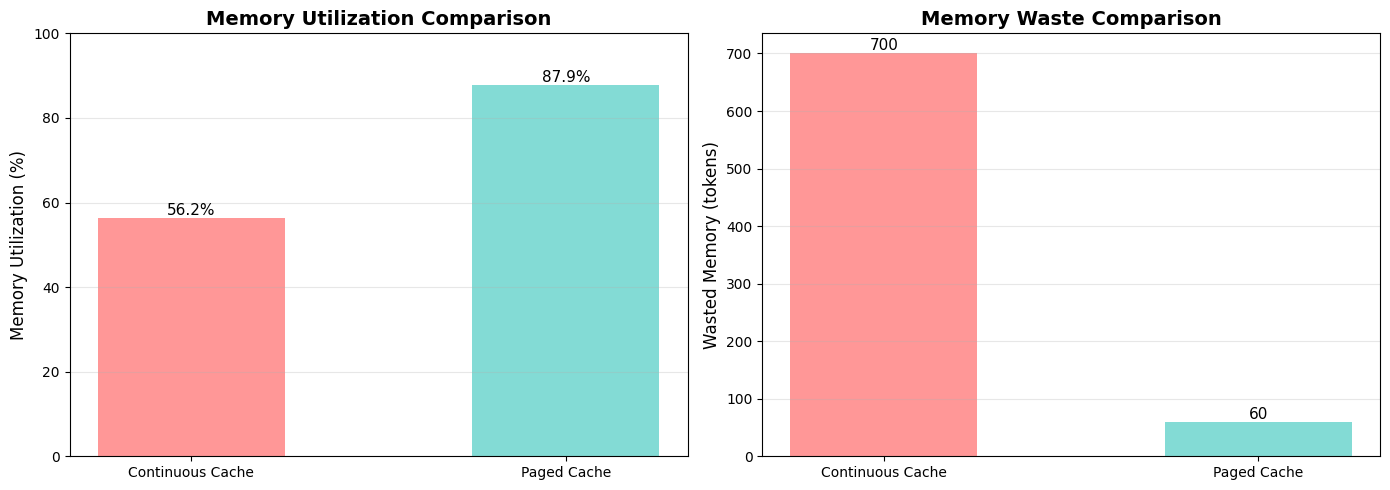

内存使用对比:
指标                   Continuous Cache     Paged Cache         
------------------------------------------------------------
已Allocate tokens     900                  900                 
浪费 tokens           700                  60                  
利用率                56.2%                87.9%
使用页面数            N/A                  60                  


In [17]:
def simulate_continuous_cache(seq_lengths, max_seq_len):
    """模拟连续 KV Cache 的内存使用"""
    total_allocated = sum(seq_lengths)
    total_wasted = max_seq_len * len(seq_lengths) - total_allocated
    utilization = total_allocated / (max_seq_len * len(seq_lengths)) * 100
    return total_allocated, total_wasted, utilization

def simulate_paged_cache(seq_lengths, page_size, num_pages):
    """模拟 Paged KV Cache 的内存使用"""
    total_pages_needed = sum((s + page_size - 1) // page_size for s in seq_lengths)
    total_allocated = sum(seq_lengths)
    total_wasted = total_pages_needed * page_size - total_allocated
    utilization = total_allocated / (num_pages * page_size) * 100 if total_pages_needed <= num_pages else 0
    return total_allocated, total_wasted, utilization, total_pages_needed

# 模拟场景：多个不同长度的Sequence
seq_lengths = [100, 50, 200, 150, 80, 120, 90, 110]
max_seq_len = 200
page_size = 16
num_pages = 64

# Continuous Cache
cont_allocated, cont_wasted, cont_util = simulate_continuous_cache(seq_lengths, max_seq_len)

# Paged Cache
paged_allocated, paged_wasted, paged_util, pages_needed = simulate_paged_cache(
    seq_lengths, page_size, num_pages
)

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Memory Utilization Comparison
categories = ['Continuous Cache', 'Paged Cache']
utilizations = [cont_util, paged_util]
colors = ['#ff6b6b', '#4ecdc4']

bars = ax1.bar(categories, utilizations, color=colors, alpha=0.7, width=0.5)
ax1.set_ylabel('Memory Utilization (%)', fontsize=12)
ax1.set_title('Memory Utilization Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, util in zip(bars, utilizations):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{util:.1f}%', ha='center', va='bottom', fontsize=11)

# Memory Waste Comparison
wasted = [cont_wasted, paged_wasted]
bars2 = ax2.bar(categories, wasted, color=colors, alpha=0.7, width=0.5)
ax2.set_ylabel('Wasted Memory (tokens)', fontsize=12)
ax2.set_title('Memory Waste Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, waste in zip(bars2, wasted):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{waste:.0f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("内存使用对比:")
print(f"{'指标':<20} {'Continuous Cache':<20} {'Paged Cache':<20}")
print("-" * 60)
print(f"{'已Allocate tokens':<20} {cont_allocated:<20} {paged_allocated:<20}")
print(f"{'浪费 tokens':<19} {cont_wasted:<20.0f} {paged_wasted:<20.0f}")
print(f"{'利用率':<18} {cont_util:<2.1f}% {'':<14} {paged_util:<2.1f}%")
print(f"{'使用页面数':<16} {'N/A':<20} {pages_needed:<20}")

In [5]:
# 创建新的缓存
cache = PagedKVCache(num_heads=8, head_dim=64, page_size=16, num_pages=32)

print("初始状态:")
stats = cache.get_statistics()
print(f"  总页面数: {stats['total_pages']}")
print(f"  Free页面: {stats['free_pages']}")
print(f"  使用页面: {stats['used_pages']}")

# Allocate多个Sequence
sequences = [
    (0, 50),   # Sequence0: 50 tokens
    (1, 30),   # Sequence1: 30 tokens
    (2, 100),  # Sequence2: 100 tokens
    (3, 20),   # Sequence3: 20 tokens
]

print("\nAllocateSequence:")
for seq_id, num_tokens in sequences:
    allocated = cache.allocate(seq_id, num_tokens)
    print(f"  Sequence {seq_id}: {num_tokens} tokens, Allocate {len(allocated)} 页")

stats = cache.get_statistics()
print(f"\nAllocate后状态:")
print(f"  使用页面: {stats['used_pages']}")
print(f"  Free页面: {stats['free_pages']}")
print(f"  利用率: {stats['usage_ratio']*100:.1f}%")

# 删除Sequence1和Sequence3
print("\n删除Sequence1和Sequence3:")
cache.free(1)
cache.free(3)

stats = cache.get_statistics()
print(f"  使用页面: {stats['used_pages']}")
print(f"  Free页面: {stats['free_pages']}")
print(f"  利用率: {stats['usage_ratio']*100:.1f}%")

# Allocate新Sequence
print("\nAllocate新Sequence4 (80 tokens):")
allocated = cache.allocate(4, 80)
print(f"  Allocate {len(allocated)} 页")
print(f"  页面ID: {allocated}")

stats = cache.get_statistics()
print(f"\n最终状态:")
print(f"  使用页面: {stats['used_pages']}")
print(f"  Free页面: {stats['free_pages']}")
print(f"  利用率: {stats['usage_ratio']*100:.1f}%")

初始状态:
  总页面数: 32
  Free页面: 32
  使用页面: 0

AllocateSequence:
  Sequence 0: 50 tokens, Allocate 4 页
  Sequence 1: 30 tokens, Allocate 2 页
  Sequence 2: 100 tokens, Allocate 7 页
  Sequence 3: 20 tokens, Allocate 2 页

Allocate后状态:
  使用页面: 15
  Free页面: 17
  利用率: 46.9%

删除Sequence1和Sequence3:
  使用页面: 11
  Free页面: 21
  利用率: 34.4%

Allocate新Sequence4 (80 tokens):
  Allocate 5 页
  页面ID: [15, 16, 17, 18, 19]

最终状态:
  使用页面: 16
  Free页面: 16
  利用率: 50.0%


## 6. 与 XQA 实现的对应关系

Paged KV Cache 在 TensorRT-LLM XQA 中得到了高度优化的实现。

### 6.1 关键对应点

| Python 实现 | XQA CUDA 实现 | 文件位置 |
|-----------|-------------|---------|
| `PagedKVCache` | Paged KV Cache | `cpp/kernels/xqa/defines.h` |
| `page_size` | `TOKENS_PER_PAGE` | `defines.h:92` |
| 页面表 | `pageList` | `mha.cu` |
| 页面索引 | `KVCachePageIndex` | `defines.h:76` |

### 6.2 XQA 的页面配置

```cpp
// defines.h
#define TOKENS_PER_PAGE 32  // 每个页面的 token 数
#define USE_PAGED_KV_CACHE (TOKENS_PER_PAGE > 0)

// 页面索引类型
using KVCachePageIndex = int32_t;
```

### 6.3 内存布局模式

XQA 支持两种内存布局：

```mermaid
graph TB
    A[Paged KV Cache] --> B[Layout 0: Original]
    A --> C[Layout 1: VLLM]
    
    B --> D[页面连续存储<br/>适合固定长度序列]
    C --> E[页面分散存储<br/>适合动态长度序列]
    
    style B fill:#4ecdc4
    style C fill:#95e1d3
```

### 6.4 学习建议

1. **理解页面管理**: 掌握页面分配和回收机制
2. **理解内存布局**: 理解两种布局模式的优缺点
3. **性能分析**: 分析页面大小对性能的影响
4. **对比学习**: 对比连续 Cache 和 Paged Cache 的性能

## 7. 总结

### 核心要点

1. **Paged KV Cache 的核心优势**:
   - 内存利用率高：固定大小页面，易于管理
   - 动态分配：支持序列的动态增长
   - 页面重用：删除序列后，页面可以立即重用
   - 减少碎片：避免内存碎片问题

2. **关键机制**:
   - **页面池**: 全局页面池，统一管理
   - **页面表**: 记录每个序列的页面映射
   - **动态分配**: 根据序列长度动态分配页面
   - **页面回收**: 删除序列后回收页面

3. **与 XQA 的关系**:
   - XQA 在 CUDA 层面实现了 Paged KV Cache
   - 支持两种内存布局模式
   - 使用页面索引优化内存访问

### 下一步学习

- 深入理解 XQA 的页面管理实现
- 学习页面大小对性能的影响
- 掌握内存布局优化技巧
- 性能分析和调优实践

---

**参考资源**:
- [vLLM PagedAttention 论文](https://arxiv.org/abs/2309.06180)
- [vLLM 源码](https://github.com/vllm-project/vllm)
- [XQA 源码](../cpp/kernels/xqa/)